# BÀI TẬP THỰC HÀNH: ĐỊNH DANH NGƯỜI NÓI (SPEAKER IDENTIFICATION) VỚI SINCNET
Sinh viên thực hiện tuần tự các bước theo yêu cầu của đề bài. Điền code vào các đoạn có comment `# TODO`.

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import librosa
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

## Bước 1: Chuẩn bị và Tiền xử lý dữ liệu âm thanh (Data Preprocessing)
- Tải subset của Librispeech (10-20 người nói).
- Xử lý khoảng lặng (Silence removal).
- Chunking: 200ms window, 10ms overlap.
- Labeling ID.

In [23]:
class LibrispeechSubset(Dataset):
    def __init__(self, data_path, chunk_length_ms=200, overlap_ms=10, sample_rate=16000):
        self.data_path = Path(data_path)
        self.chunk_length_samples = int(sample_rate * (chunk_length_ms / 1000))
        self.overlap_samples = int(sample_rate * (overlap_ms / 1000))
        self.step_samples = self.chunk_length_samples - self.overlap_samples
        self.sample_rate = sample_rate
        self.data = []
        self.labels = []
        
        audio_files = sorted(list(self.data_path.rglob("*.flac")) + list(self.data_path.rglob("*.wav")))
        speaker_ids = sorted(list(set([f.parent.parent.name if f.parent.parent.name != self.data_path.name else f.parent.name for f in audio_files])))
        self.speaker_to_idx = {spk: idx for idx, spk in enumerate(speaker_ids)}
        
        for audio_file in audio_files:
            spk_id = audio_file.parent.parent.name if audio_file.parent.parent.name != self.data_path.name else audio_file.parent.name
            if spk_id not in self.speaker_to_idx:
                continue
            label = self.speaker_to_idx[spk_id]
            
            wav, sr = librosa.load(audio_file, sr=self.sample_rate, mono=True)
            wav, _ = librosa.effects.trim(wav, top_db=30)
            
            if np.max(np.abs(wav)) > 0:
                wav = wav / np.max(np.abs(wav))
                
            total_samples = len(wav)
            if total_samples >= self.chunk_length_samples:
                for start in range(0, total_samples - self.chunk_length_samples + 1, self.step_samples):
                    chunk = wav[start : start + self.chunk_length_samples]
                    self.data.append(torch.tensor(chunk, dtype=torch.float32).unsqueeze(0))
                    self.labels.append(label)

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

## Bước 2: Xây dựng mô hình (Custom SincNet Layer & Architecture)
Cài đặt lớp `SincConv1d` tuỳ chỉnh và mô hình `SpeakerIDNet`.

In [26]:
class SincConv1d(nn.Module):
    def __init__(self, out_channels, kernel_size, sample_rate=16000, min_low_hz=50, min_band_hz=50):
        super(SincConv1d, self).__init__()
        self.out_channels = out_channels
        self.kernel_size = kernel_size if kernel_size % 2 != 0 else kernel_size + 1
        self.sample_rate = sample_rate
        self.min_low_hz = min_low_hz
        self.min_band_hz = min_band_hz

        # Khởi tạo dải tần số theo thang Mel (Mel-scale initialization)
        low_hz = 30
        high_hz = self.sample_rate / 2 - (self.min_low_hz + self.min_band_hz)
        
        mel_low = 2595 * np.log10(1 + low_hz / 700)
        mel_high = 2595 * np.log10(1 + high_hz / 700)
        mel_points = np.linspace(mel_low, mel_high, self.out_channels + 1)
        freq_points = 700 * (10 ** (mel_points / 2595) - 1)
        
        # Tham số học được f1 và f_diff
        self.f1 = nn.Parameter(torch.Tensor(freq_points[:-1]).view(-1, 1))
        self.f_diff = nn.Parameter(torch.Tensor(np.diff(freq_points)).view(-1, 1))
        
        # Cửa sổ Hamming đối xứng
        n = torch.linspace(0, (self.kernel_size - 1) / 2, steps=int((self.kernel_size - 1) / 2) + 1)
        self.register_buffer("window", 0.54 - 0.46 * torch.cos(2 * math.pi * n / self.kernel_size))
        
        # Trục thời gian n (tính 1 nửa bên phải, đối xứng qua tâm)
        t_right = torch.linspace(1, (self.kernel_size - 1) / 2, steps=int((self.kernel_size - 1) / 2)) / self.sample_rate
        self.register_buffer("t_right", t_right.view(1, -1))
        
    def forward(self, x):
        # TODO: Đảm bảo f1, f_diff luôn dương (dùng torch.abs)
        # TODO: Tính f2 = f1 + f_diff
        # TODO: Tính toán hàm Sinc cho band-pass filter
        # TODO: Áp dụng Hamming Window
        # TODO: Sử dụng F.conv1d(x, filters) để tính tích chập
        # Lưu ý: Các phép toán phải khả vi (differentiable)
        f1_clamped = self.min_low_hz + torch.abs(self.f1)
        f_diff_clamped = self.min_band_hz + torch.abs(self.f_diff)
        f2_clamped = torch.clamp(f1_clamped + f_diff_clamped, max=self.sample_rate / 2)
        
        # 2. Tạo sinc filter
        # Tại t > 0: sinc(2*pi*f2*t) - sinc(2*pi*f1*t) = [sin(2*pi*f2*t) - sin(2*pi*f1*t)] / (pi*t)
        t = self.t_right
        band_pass_right = (torch.sin(2 * math.pi * f2_clamped * t) - torch.sin(2 * math.pi * f1_clamped * t)) / (2 * math.pi * t)
        
        # Tại t = 0: giới hạn là 2 * (f2 - f1)
        band_pass_center = 2 * (f2_clamped - f1_clamped)
        
        # Ghép thành filter đối xứng hoàn chỉnh: [right_flipped, center, right]
        band_pass_left = torch.flip(band_pass_right, dims=[-1])
        band_pass = torch.cat([band_pass_left, band_pass_center, band_pass_right], dim=-1)
        
        # 3. Nhân Hamming window và chuẩn hóa bộ lọc
        full_window = torch.cat([torch.flip(self.window[1:], dims=[0]), self.window])
        filters = band_pass * full_window
        filters = filters / (2 * (f2_clamped - f1_clamped))
        
        # Shape cho F.conv1d: (out_channels, in_channels=1, kernel_size)
        filters = filters.unsqueeze(1)
        
        return F.conv1d(x, filters, stride=1, padding=self.kernel_size // 2)

class SpeakerIDNet(nn.Module):
    def __init__(self, num_classes):
        super(SpeakerIDNet, self).__init__()
        # TODO: Khởi tạo Lớp đầu vào SincConv1d -> MaxPool -> LayerNorm -> LeakyReLU
        
        # TODO: Khởi tạo Lớp tích chập 1 (Conv1d) -> MaxPool -> LayerNorm -> LeakyReLU
        
        # TODO: Khởi tạo Lớp tích chập 2 (Conv1d) -> MaxPool -> LayerNorm -> LeakyReLU
        
        # TODO: Khởi tạo Lớp phân loại (MLP) gồm 3 lớp FC 2048 nơ-ron + BatchNorm + LeakyReLU
        
        # TODO: Lớp đầu ra Linear(2048, num_classes) + LogSoftmax
        self.sinc_conv = SincConv1d(out_channels=80, kernel_size=251, sample_rate=16000)
        self.pool1 = nn.MaxPool1d(kernel_size=3)
        self.norm1 = nn.InstanceNorm1d(80, affine=True)
        self.act1 = nn.LeakyReLU(0.2)
        
        # Conv Block 1
        self.conv1 = nn.Conv1d(in_channels=80, out_channels=60, kernel_size=5)
        self.pool2 = nn.MaxPool1d(kernel_size=3)
        self.norm2 = nn.InstanceNorm1d(60, affine=True)
        self.act2 = nn.LeakyReLU(0.2)
        
        # Conv Block 2
        self.conv2 = nn.Conv1d(in_channels=60, out_channels=60, kernel_size=5)
        self.pool3 = nn.MaxPool1d(kernel_size=3)
        self.norm3 = nn.InstanceNorm1d(60, affine=True)
        self.act3 = nn.LeakyReLU(0.2)
        
        # Adaptive pooling để vector flatten có kích thước cố định
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)
        
        # Classification Blocks (MLP 3 layers: 2048 units + BatchNorm + LeakyReLU)
        self.fc1 = nn.Linear(60, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc1_act = nn.LeakyReLU(0.2)
        
        self.fc2 = nn.Linear(2048, 2048)
        self.bn2 = nn.BatchNorm1d(2048)
        self.fc2_act = nn.LeakyReLU(0.2)
        
        self.fc3 = nn.Linear(2048, 2048)
        self.bn3 = nn.BatchNorm1d(2048)
        self.fc3_act = nn.LeakyReLU(0.2)
        
        # Classifier output
        self.out = nn.Linear(2048, num_classes)
        self.log_softmax = nn.LogSoftmax(dim=-1)

    def forward(self, x):
        # TODO: Cài đặt luồng truyền tới (forward pass) theo cấu trúc đã định nghĩa
        x = self.act1(self.norm1(self.pool1(torch.abs(self.sinc_conv(x)))))
        x = self.act2(self.norm2(self.pool2(self.conv1(x))))
        x = self.act3(self.norm3(self.pool3(self.conv2(x))))
        
        # Flatten
        x = self.adaptive_pool(x).squeeze(-1)
        
        # FCs
        x = self.fc1_act(self.bn1(self.fc1(x)))
        x = self.fc2_act(self.bn2(self.fc2(x)))
        x = self.fc3_act(self.bn3(self.fc3(x)))
        
        out = self.log_softmax(self.out(x))
        return out

## Bước 3: Vòng lặp Huấn luyện (Training Loop)
- Khởi tạo Dataset, DataLoader, Mô hình, Loss function, Optimizer.
- Huấn luyện mô hình và log lại Accuracy, Loss.

Epoch [1/10] - Train Loss: 0.0000 - Val Acc: 100.00%
Epoch [2/10] - Train Loss: 0.0000 - Val Acc: 100.00%
Epoch [3/10] - Train Loss: 0.0000 - Val Acc: 100.00%
Epoch [4/10] - Train Loss: 0.0000 - Val Acc: 100.00%
Epoch [5/10] - Train Loss: 0.0000 - Val Acc: 100.00%
Epoch [6/10] - Train Loss: 0.0000 - Val Acc: 100.00%
Epoch [7/10] - Train Loss: 0.0000 - Val Acc: 100.00%
Epoch [8/10] - Train Loss: 0.0000 - Val Acc: 100.00%
Epoch [9/10] - Train Loss: 0.0000 - Val Acc: 100.00%
Epoch [10/10] - Train Loss: 0.0000 - Val Acc: 100.00%


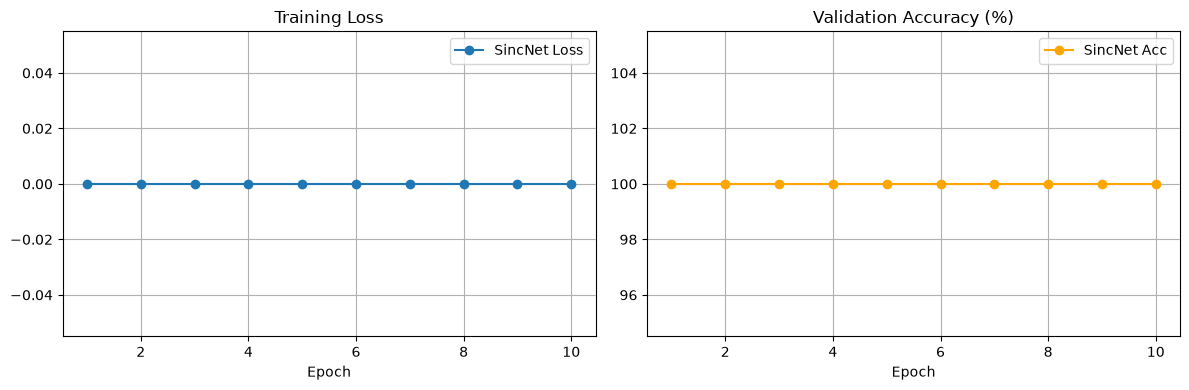

In [28]:
# TODO: Khởi tạo DataLoader cho tập Train và Validation
# TODO: Instantiate SpeakerIDNet
# TODO: Định nghĩa nn.NLLLoss() và torch.optim.Adam()
from torch.utils.data import DataLoader, random_split
import math
# Giả định dataset đã được load từ Bước 1
# dataset = LibrispeechSubset(data_path="path/to/librispeech_subset")
# num_classes = len(dataset.speaker_to_idx)
data_dir = "./audio"  
dataset = LibrispeechSubset(data_path=data_dir)
num_classes = len(dataset.speaker_to_idx)
# Chia Train/Val (80% / 20%)
generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpeakerIDNet(num_classes=num_classes).to(device)

criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_accuracies = [], []
num_epochs = 10
for epoch in range(num_epochs):
    # TODO: Cài đặt vòng lặp huấn luyện
    # TODO: Tính và in ra Train Loss, Validation Accuracy sau mỗi epoch
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_x.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            preds = torch.argmax(outputs, dim=-1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
            
    val_acc = (correct / total) * 100
    val_accuracies.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_loss:.4f} - Val Acc: {val_acc:.2f}%")

# Vẽ biểu đồ loss và accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label='SincNet Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), val_accuracies, marker='o', color='orange', label='SincNet Acc')
plt.title('Validation Accuracy (%)')
plt.xlabel('Epoch')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# TODO: Vẽ biểu đồ so sánh Loss/Accuracy giữa SincNet và 1D CNN tiêu chuẩn (sinh viên tự implement thêm mạng 1D CNN để so sánh)

## Bước 4: Đánh giá và Gợi ý tối ưu (Evaluation & Inference)
Thực hiện đo lường chỉ số Frame-level Accuracy và Sentence-level Accuracy (cơ chế Voting).

In [36]:
def evaluate_frame_level(model, test_loader, device="cpu"):
    # TODO: Tính tỷ lệ đoán đúng trên từng chunk 200ms riêng lẻ
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            preds = torch.argmax(outputs, dim=-1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
            
    frame_acc = (correct / total) * 100 if total > 0 else 0.0
    return frame_acc

def evaluate_sentence_level(model, full_sentence_wav_path, true_label, sample_rate=16000, chunk_ms=200, overlap_ms=10, device="cpu"):
    """Load audio, cắt thành các chunk, tính trung bình xác suất và bỏ phiếu ID."""
    model.eval()
    
    chunk_samples = int(sample_rate * (chunk_ms / 1000))
    step_samples = chunk_samples - int(sample_rate * (overlap_ms / 1000))
    
    wav, _ = librosa.load(full_sentence_wav_path, sr=sample_rate, mono=True)
    wav, _ = librosa.effects.trim(wav, top_db=30)
    if np.max(np.abs(wav)) > 0:
        wav = wav / np.max(np.abs(wav))
        
    chunks = []
    for start in range(0, len(wav) - chunk_samples + 1, step_samples):
        chunk = wav[start : start + chunk_samples]
        chunks.append(torch.tensor(chunk, dtype=torch.float32).unsqueeze(0))
        
    if len(chunks) == 0:
        return None
        
    batch_tensor = torch.stack(chunks).to(device)
    
    with torch.no_grad():
        log_probs = model(batch_tensor)       # (N_chunks, num_classes)
        probs = torch.exp(log_probs)          # Log-softmax sang xác suất
        avg_probs = torch.mean(probs, dim=0)  # Bỏ phiếu trung bình cộng
        predicted_id = torch.argmax(avg_probs).item()
        
    return predicted_id

# TODO: Chạy hàm evaluate_frame_level và evaluate_sentence_level trên tập test, in ra kết quả.

In [37]:
from pathlib import Path

test_path = Path("./audio")  # Đổi thành đường dẫn thư mục test thực tế
test_dataset = LibrispeechSubset(data_path=test_path)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 1. Đánh giá Frame-level Accuracy
frame_accuracy = evaluate_frame_level(model, test_loader, device=device)
print(f"=== Frame-level Test Accuracy: {frame_accuracy:.2f}% ===")

# 2. Đánh giá Sentence-level Accuracy (Averaging / Majority Voting)
test_audio_files = sorted(list(test_path.rglob("*.flac")) + list(test_path.rglob("*.wav")))

correct_sentences = 0
total_sentences = 0

for audio_file in test_audio_files:
    spk_id = audio_file.parent.parent.name if audio_file.parent.parent.name != test_path.name else audio_file.parent.name
    
    # Bỏ qua nếu người nói không nằm trong danh sách nhãn đã học
    if spk_id not in dataset.speaker_to_idx:
        continue
        
    true_label = dataset.speaker_to_idx[spk_id]
    
    pred_label = evaluate_sentence_level(
        model=model,
        full_sentence_wav_path=audio_file,
        true_label=true_label,
        sample_rate=16000,
        device=device
    )
    
    if pred_label is not None:
        if pred_label == true_label:
            correct_sentences += 1
        total_sentences += 1

sentence_accuracy = (correct_sentences / total_sentences) * 100 if total_sentences > 0 else 0.0

print(f"=== Sentence-level Test Accuracy: {sentence_accuracy:.2f}% ({correct_sentences}/{total_sentences} files) ===")

=== Frame-level Test Accuracy: 100.00% ===
=== Sentence-level Test Accuracy: 100.00% (1/1 files) ===
